# **Grad-CAM Faithfulness Comparison — ECA vs SA vs CBAM (ResNet50)**

Membandingkan 3 varian attention module lewat dua hal:

1. **Faithfulness metrics** (Average Drop % & Increase in Confidence %) dihitung di seluruh test set.
2. **Visualisasi 1 foto** — heatmap Grad-CAM tiap varian ditampilkan berdampingan.

**REVISI PENTING dari draft sebelumnya**: draft pertama salah asumsi bahwa attention disisipkan di 1 titik seragam (`layer4`) untuk semua varian, seperti pola ViT. Ternyata arsitektur tiap varian BEDA-BEDA (dicek langsung dari `exp02-cnn-eca.ipynb`, `exp03-cnn-sa.ipynb`, `exp04-cnn-cbam.ipynb`):

| Varian | Titik insersi | Cakupan |
|---|---|---|
| **Baseline** | — | timm `resnet50` polos, tidak ada modul attention |
| **ECA** | slot `.se` bawaan timm | **SETIAP** Bottleneck block, `layer1` s/d `layer4` (semua stage) |
| **CBAM** | slot `.se` bawaan timm | **SETIAP** Bottleneck block, `layer1` s/d `layer4` (semua stage) |
| **SA** (non-local self-attention) | 1 titik tunggal, di `ResNetSA.attention` | HANYA di feature map akhir backbone (2048, 7x7), sebelum global average pooling — bukan per-block |

Karena itu, `load_model()` harus membangun ulang arsitektur **persis sesuai notebook training masing-masing**, bukan generik satu pola untuk semua.

**Titik hook Grad-CAM (Level 1 / Level 2)** juga didesain ulang supaya tetap adil dibandingkan lintas varian yang strukturnya berbeda:
- **Level 1 — akhir `layer2`** (representasi mid-level, 512 channel): untuk ECA/CBAM ini adalah output `layer2[-1].se` (sudah kena attention); untuk Baseline & SA ini adalah `layer2[-1]` polos (SA memang tidak punya attention di titik ini — itu justru bagian dari perbandingan yang ingin dilihat: apakah attention "menyebar" seperti ECA/CBAM beda pengaruhnya dari attention "terpusat di akhir" seperti SA).
- **Level 2 — "decision layer"**, feature map terakhir sebelum `avgpool`: untuk ECA/CBAM ini `layer4[-1].se`; untuk SA ini `model.attention` (titik yang memang didesain di situ); untuk Baseline ini `layer4[-1]` polos. Titik ini SELALU ada dan SELALU merupakan representasi paling dekat ke keputusan akhir di keempat varian, jadi ini titik paling adil untuk dibandingkan.

# **Import Library**

In [10]:
import os
import copy
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from PIL import Image
from tqdm import tqdm

import timm
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


# **Dataset Path & Config**

In [11]:

TRAIN_DIR = "/kaggle/input/datasets/shubhamgoel27/dermnet/train"   
TEST_DIR  = "/kaggle/input/datasets/shubhamgoel27/dermnet/test"

classes      = sorted(os.listdir(TRAIN_DIR))
num_classes  = len(classes)

eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_tf)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)

MAX_SAMPLES = None

DROPOUT = 0.3   # sama dengan semua notebook training (EXP01-04)

# Hyperparameter modul attention -- disalin PERSIS dari config masing-masing
# notebook training, supaya arsitektur yang dibangun ulang di sini identik
# dengan yang dipakai saat training checkpoint.
ECA_K_SIZE               = 3    # exp02-cnn-eca.ipynb
SA_REDUCTION              = 8    # exp03-cnn-sa.ipynb
CBAM_REDUCTION_RATIO      = 16   # exp04-cnn-cbam.ipynb
CBAM_SPATIAL_KERNEL_SIZE  = 7    # exp04-cnn-cbam.ipynb


# **Definisi Arsitektur per Varian**

Disalin persis dari notebook training masing-masing (`exp02-cnn-eca.ipynb`, `exp03-cnn-sa.ipynb`, `exp04-cnn-cbam.ipynb`) -- kelas modul attention + fungsi/kelas yang menyisipkannya ke backbone. Kalau notebook training direvisi lagi nanti, bagian ini WAJIB disinkronkan ulang, kalau tidak `load_state_dict` akan gagal lagi seperti sebelumnya.

In [12]:
# ══════════════════════════════════════════════════════════════════════════
# ECA -- disalin dari exp02-cnn-eca.ipynb
# ══════════════════════════════════════════════════════════════════════════
class ECAAttention(nn.Module):
    def __init__(self, channels, k_size=3):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k_size, padding=(k_size - 1) // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        y = self.avg_pool(x)
        y = y.squeeze(-1).transpose(-1, -2)
        y = self.conv(y)
        y = y.transpose(-1, -2).unsqueeze(-1)
        y = self.sigmoid(y)
        return x * y.expand_as(x)


def inject_eca(model, k_size=3):
    n_injected = 0
    for layer_name in ["layer1", "layer2", "layer3", "layer4"]:
        layer = getattr(model, layer_name, None)
        if layer is None:
            continue
        for block in layer:
            channels = block.bn3.num_features
            block.se = ECAAttention(channels, k_size=k_size)
            n_injected += 1
    print(f"  [ECA] Disisipkan ke {n_injected} Bottleneck block (layer1-4).")
    return model


In [13]:
# ══════════════════════════════════════════════════════════════════════════
# CBAM -- disalin dari exp04-cnn-cbam.ipynb
# ══════════════════════════════════════════════════════════════════════════
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction_ratio=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        hidden = max(channels // reduction_ratio, 1)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, hidden, kernel_size=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, kernel_size=1, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))
        y = self.sigmoid(avg_out + max_out)
        return x * y


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=(kernel_size - 1) // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        y = torch.cat([avg_out, max_out], dim=1)
        y = self.conv(y)
        y = self.sigmoid(y)
        return x * y


class CBAMAttention(nn.Module):
    def __init__(self, channels, reduction_ratio=16, spatial_kernel_size=7):
        super().__init__()
        self.channel_attention = ChannelAttention(channels, reduction_ratio)
        self.spatial_attention = SpatialAttention(spatial_kernel_size)

    def forward(self, x):
        x = self.channel_attention(x)
        x = self.spatial_attention(x)
        return x


def inject_cbam(model, reduction_ratio=16, spatial_kernel_size=7):
    n_injected = 0
    for layer_name in ["layer1", "layer2", "layer3", "layer4"]:
        layer = getattr(model, layer_name, None)
        if layer is None:
            continue
        for block in layer:
            channels = block.bn3.num_features
            block.se = CBAMAttention(channels, reduction_ratio=reduction_ratio, spatial_kernel_size=spatial_kernel_size)
            n_injected += 1
    print(f"  [CBAM] Disisipkan ke {n_injected} Bottleneck block (layer1-4).")
    return model


In [14]:
# ══════════════════════════════════════════════════════════════════════════
# SA (non-local self-attention, gaya SAGAN) -- disalin dari exp03-cnn-sa.ipynb
# ══════════════════════════════════════════════════════════════════════════
class SelfAttention2d(nn.Module):
    def __init__(self, in_dim, reduction=8):
        super().__init__()
        reduced_dim = max(in_dim // reduction, 1)
        self.query_conv = nn.Conv2d(in_dim, reduced_dim, kernel_size=1)
        self.key_conv   = nn.Conv2d(in_dim, reduced_dim, kernel_size=1)
        self.value_conv = nn.Conv2d(in_dim, in_dim, kernel_size=1)
        self.gamma = nn.Parameter(torch.zeros(1))
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x, return_attention=False):
        B, C, H, W = x.shape
        N = H * W

        proj_query = self.query_conv(x).view(B, -1, N).permute(0, 2, 1)
        proj_key   = self.key_conv(x).view(B, -1, N)
        energy     = torch.bmm(proj_query, proj_key)
        attn       = self.softmax(energy)

        proj_value = self.value_conv(x).view(B, -1, N)
        out = torch.bmm(proj_value, attn.permute(0, 2, 1))
        out = out.view(B, C, H, W)

        out = self.gamma * out + x

        if return_attention:
            return out, attn
        return out


class ResNetSA(nn.Module):
    """PENTING: beda struktur dari ECA/CBAM. Backbone disimpan di
    self.backbone (num_classes=0, global_pool="" -> forward_features()
    mengembalikan feature map mentah [B, 2048, 7, 7]), attention hanya SATU
    modul di self.attention yang diterapkan ke feature map akhir, baru
    dipool+FC. Ini kenapa titik hook Grad-CAM untuk SA beda cara aksesnya
    dibanding ECA/CBAM (lihat get_target_layer di bawah)."""
    def __init__(self, timm_name, num_classes, dropout=DROPOUT, sa_reduction=SA_REDUCTION):
        super().__init__()
        self.backbone = timm.create_model(
            timm_name, pretrained=True, num_classes=0, global_pool=""
        )
        feat_dim = self.backbone.num_features

        self.attention = SelfAttention2d(feat_dim, reduction=sa_reduction)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(feat_dim, num_classes)

    def forward(self, x, return_attention=False):
        feats = self.backbone.forward_features(x)
        attended = self.attention(feats, return_attention=return_attention)
        if return_attention:
            attended, attn_map = attended

        pooled = self.pool(attended).flatten(1)
        pooled = self.dropout(pooled)
        logits = self.fc(pooled)

        if return_attention:
            return logits, attn_map
        return logits


# **Konfigurasi Varian & Model Loader**

In [15]:
VARIANT_CONFIGS = {
    "Baseline": {
        "checkpoint": "/kaggle/input/models/devianestnarendra/cnn-gradcam-test/other/default/1/CNN_Base_model_fold_4.pth",  # TODO: isi path checkpoint Baseline
        "kind": "plain",
    },
    "ECA": {
        "checkpoint": "/kaggle/input/models/devianestnarendra/cnn-gradcam-test/other/default/1/CNN_ECA_model_fold_5.pth",  # TODO: isi path checkpoint ECA
        "kind": "per_block",   # attention di setiap Bottleneck, slot .se
    },
    "SA": {
        "checkpoint": "/kaggle/input/models/devianestnarendra/cnn-gradcam-test/other/default/1/CNN_SA_model_fold_1.pth",  # TODO: isi path checkpoint SA
        "kind": "single_point",   # attention 1 titik, setelah backbone
    },
    "CBAM": {
        "checkpoint": "/kaggle/input/models/devianestnarendra/cnn-gradcam-test/other/default/1/CNN_CBAM_model_fold_4.pth",  # TODO: isi path checkpoint CBAM
        "kind": "per_block",
    },
}


def load_model(variant_name, num_classes, device):
    """Bangun ulang arsitektur PERSIS sesuai notebook training masing-masing
    varian (bukan 1 pola generik) -- lihat cell definisi arsitektur di atas."""
    cfg = VARIANT_CONFIGS[variant_name]
    kind = cfg["kind"]

    if variant_name == "Baseline":
        model = timm.create_model("resnet50", pretrained=False, num_classes=num_classes, drop_rate=DROPOUT)

    elif variant_name == "ECA":
        model = timm.create_model("resnet50", pretrained=False, num_classes=num_classes, drop_rate=DROPOUT)
        model = inject_eca(model, k_size=ECA_K_SIZE)

    elif variant_name == "CBAM":
        model = timm.create_model("resnet50", pretrained=False, num_classes=num_classes, drop_rate=DROPOUT)
        model = inject_cbam(model, reduction_ratio=CBAM_REDUCTION_RATIO, spatial_kernel_size=CBAM_SPATIAL_KERNEL_SIZE)

    elif variant_name == "SA":
        model = ResNetSA("resnet50", num_classes, dropout=DROPOUT, sa_reduction=SA_REDUCTION)

    else:
        raise ValueError(f"Varian tidak dikenal: {variant_name}")

    model = model.to(device)
    checkpoint = torch.load(cfg["checkpoint"], map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model


def get_target_layer(model, variant_name):
    """Level 1 -- akhir layer2 (representasi mid-level).
    ECA/CBAM: sudah kena attention di titik ini (layer2[-1].se).
    Baseline & SA: titik ini polos, tidak ada attention (SA memang cuma
    punya 1 titik attention, di akhir backbone -- lihat Level 2)."""
    kind = VARIANT_CONFIGS[variant_name]["kind"]

    if variant_name == "SA":
        return model.backbone.layer2[-1]
    if kind == "per_block":
        return model.layer2[-1].se
    return model.layer2[-1]   # Baseline


def get_target_layer_decision(model, variant_name):
    """Level 2 -- 'decision layer', feature map terakhir sebelum avgpool.
    Ini titik yang PALING adil untuk dibandingkan lintas varian, karena
    selalu ada dan selalu representasi paling dekat ke keputusan akhir:
    - ECA/CBAM : layer4[-1].se (attention terakhir dari backbone)
    - SA       : model.attention (satu-satunya titik attention SA, memang
                 didesain persis di posisi ini)
    - Baseline : layer4[-1] polos (tidak ada attention sama sekali)."""
    kind = VARIANT_CONFIGS[variant_name]["kind"]

    if variant_name == "SA":
        return model.attention
    if kind == "per_block":
        return model.layer4[-1].se
    return model.layer4[-1]   # Baseline


# **Grad-CAM Implementation**

In [16]:
class GradCAM:
    def __init__(self, model, target_layer, reshape_transform=None):
        self.model = model
        self.target_layer = target_layer
        self.reshape_transform = reshape_transform
        self.activations = None
        self.gradients = None
        self._fwd_handle = target_layer.register_forward_hook(self._save_activation)

    def _save_activation(self, module, inp, out):
        self.activations = out
        # PERBAIKAN: pakai tensor-level register_hook, BUKAN
        # register_full_backward_hook di level modul. Bottleneck ResNet (timm)
        # punya operasi in-place TEPAT setelah titik .se (residual add:
        # "x += shortcut"), dan register_full_backward_hook konflik dengan
        # in-place op setelahnya -> RuntimeError "Output ... is a view and is
        # being modified inplace". Hook langsung ke tensor output menghindari
        # masalah ini sepenuhnya (tidak melibatkan wrapper level-modul sama sekali).
        if out.requires_grad:
            out.register_hook(self._save_gradient)

    def _save_gradient(self, grad):
        self.gradients = grad

    def generate(self, input_tensor, class_idx=None):
        """
        input_tensor : (B, 3, H, W), sudah dinormalisasi (eval_tf)
        class_idx    : (B,) target kelas. Default = prediksi model sendiri
                       (standar untuk faithfulness eval -- bukan ground truth).
        Return: cam (B, H, W) dalam rentang [0, 1], probs (B, num_classes), class_idx (B,)
        """
        self.model.zero_grad(set_to_none=True)
        input_tensor = input_tensor.clone().requires_grad_(True)
        output = self.model(input_tensor)
        probs  = output.softmax(dim=1)

        if class_idx is None:
            class_idx = output.argmax(dim=1)

        selected = output[torch.arange(output.size(0), device=output.device), class_idx]
        selected.sum().backward()

        activations = self.activations
        gradients   = self.gradients
        if self.reshape_transform is not None:
            activations = self.reshape_transform(activations)
            gradients   = self.reshape_transform(gradients)

        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)

        cam = F.interpolate(cam, size=input_tensor.shape[-2:], mode="bilinear", align_corners=False)
        cam_flat = cam.view(cam.size(0), -1)
        cam_min  = cam_flat.min(dim=1)[0].view(-1, 1, 1, 1)
        cam_max  = cam_flat.max(dim=1)[0].view(-1, 1, 1, 1)
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)

        return cam.squeeze(1).detach(), probs.detach(), class_idx.detach()

    def remove_hooks(self):
        self._fwd_handle.remove()


# **Faithfulness Metrics — Average Drop % & Increase in Confidence %**
- **Average Drop %** = rata-rata `max(0, Y_c - O_c) / Y_c`, dikali 100. `Y_c` = confidence model pada kelas prediksi memakai gambar asli; `O_c` = confidence pada gambar yang sudah di-mask pakai CAM (elementwise `image * cam`). Semakin RENDAH semakin baik.
- **Increase in Confidence %** = persentase sample di mana `O_c > Y_c`. Semakin TINGGI semakin baik.

In [17]:
def compute_faithfulness(model, gradcam, dataloader, device, max_samples=None):
    total_drop     = 0.0
    increase_count = 0
    n_samples      = 0

    for images, _ in tqdm(dataloader, desc="Faithfulness eval"):
        images = images.to(device)

        cams, probs, pred_idx = gradcam.generate(images)
        Y = probs[torch.arange(probs.size(0), device=device), pred_idx]

        masked_images = images * cams.unsqueeze(1)
        with torch.no_grad():
            masked_output = model(masked_images)
            masked_probs  = masked_output.softmax(dim=1)
        O = masked_probs[torch.arange(masked_probs.size(0), device=device), pred_idx]

        drop = torch.clamp(Y - O, min=0) / (Y + 1e-8)
        total_drop     += drop.sum().item()
        increase_count += (O > Y).sum().item()
        n_samples      += images.size(0)

        if max_samples is not None and n_samples >= max_samples:
            break

    avg_drop_pct = (total_drop / n_samples) * 100
    iic_pct      = (increase_count / n_samples) * 100
    return avg_drop_pct, iic_pct, n_samples


# **Level 1 — Jalankan Perbandingan (akhir `layer2`)**

In [18]:
results_level1 = []

for variant_name in VARIANT_CONFIGS.keys():
    print(f"\n{'='*50}\n  {variant_name}\n{'='*50}")

    model = load_model(variant_name, num_classes, device)
    target_layer = get_target_layer(model, variant_name)
    gradcam = GradCAM(model, target_layer)

    avg_drop, iic, n = compute_faithfulness(model, gradcam, test_loader, device, max_samples=MAX_SAMPLES)
    print(f"  Average Drop %        : {avg_drop:.2f}")
    print(f"  Increase in Confidence%: {iic:.2f}")
    print(f"  N samples evaluated    : {n}")

    results_level1.append({
        "Variant": variant_name,
        "Average_Drop_%": avg_drop,
        "Increase_in_Confidence_%": iic,
        "N_samples": n,
    })

    gradcam.remove_hooks()
    del model, gradcam
    torch.cuda.empty_cache()

results_df_level1 = pd.DataFrame(results_level1)
print("\n", results_df_level1)

os.makedirs("outputs", exist_ok=True)
results_df_level1.to_csv("outputs/GradCAM_Faithfulness_Comparison_Level1_Layer2.csv", index=False)
print("\n✓ Hasil disimpan -> outputs/GradCAM_Faithfulness_Comparison_Level1_Layer2.csv")



  Baseline


Faithfulness eval: 100%|██████████| 251/251 [01:15<00:00,  3.35it/s]


  Average Drop %        : 84.17
  Increase in Confidence%: 3.70
  N samples evaluated    : 4002

  ECA
  [ECA] Disisipkan ke 16 Bottleneck block (layer1-4).


Faithfulness eval: 100%|██████████| 251/251 [01:24<00:00,  2.99it/s]


  Average Drop %        : 80.74
  Increase in Confidence%: 4.50
  N samples evaluated    : 4002

  SA


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Faithfulness eval: 100%|██████████| 251/251 [01:20<00:00,  3.11it/s]


  Average Drop %        : 84.37
  Increase in Confidence%: 2.72
  N samples evaluated    : 4002

  CBAM
  [CBAM] Disisipkan ke 16 Bottleneck block (layer1-4).


Faithfulness eval: 100%|██████████| 251/251 [01:42<00:00,  2.46it/s]

  Average Drop %        : 83.36
  Increase in Confidence%: 4.25
  N samples evaluated    : 4002

     Variant  Average_Drop_%  Increase_in_Confidence_%  N_samples
0  Baseline       84.173150                  3.698151       4002
1       ECA       80.738896                  4.497751       4002
2        SA       84.373424                  2.723638       4002
3      CBAM       83.357312                  4.247876       4002

✓ Hasil disimpan -> outputs/GradCAM_Faithfulness_Comparison_Level1_Layer2.csv


# **Level 1 — Grafik Perbandingan**

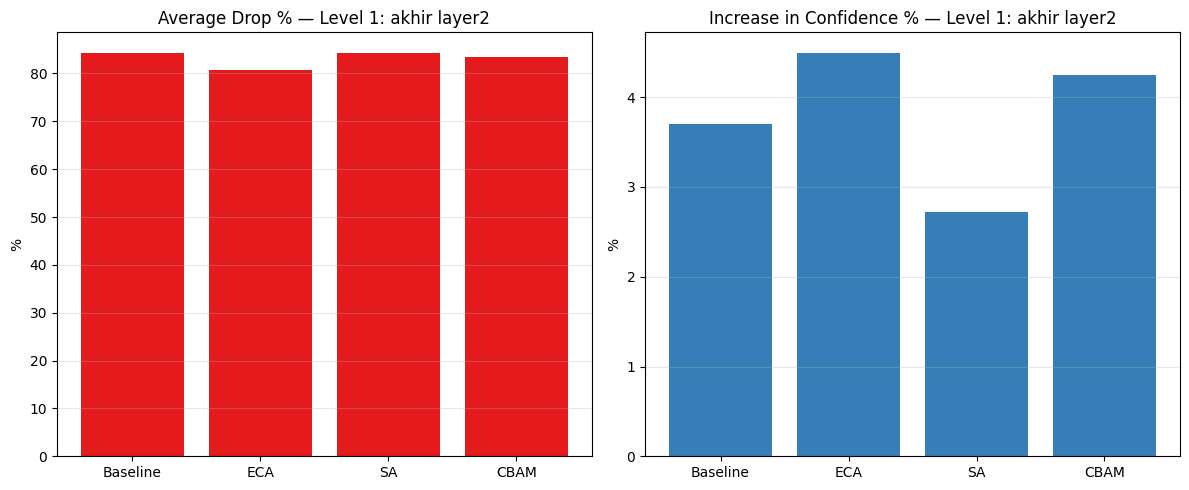

✓ Grafik disimpan -> outputs/GradCAM_Faithfulness_BarChart_Level1.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(results_df_level1["Variant"], results_df_level1["Average_Drop_%"], color="#e41a1c")
axes[0].set_title("Average Drop % — Level 1: akhir layer2")
axes[0].set_ylabel("%")
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].bar(results_df_level1["Variant"], results_df_level1["Increase_in_Confidence_%"], color="#377eb8")
axes[1].set_title("Increase in Confidence % — Level 1: akhir layer2")
axes[1].set_ylabel("%")
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/GradCAM_Faithfulness_BarChart_Level1.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Grafik disimpan -> outputs/GradCAM_Faithfulness_BarChart_Level1.png")


# **Level 2 — Jalankan Perbandingan (Decision Layer, akhir `layer4`)**

In [20]:
results_level2 = []

for variant_name in VARIANT_CONFIGS.keys():
    print(f"\n{'='*50}\n  {variant_name}\n{'='*50}")

    model = load_model(variant_name, num_classes, device)
    target_layer = get_target_layer_decision(model, variant_name)
    gradcam = GradCAM(model, target_layer)

    avg_drop, iic, n = compute_faithfulness(model, gradcam, test_loader, device, max_samples=MAX_SAMPLES)
    print(f"  Average Drop %        : {avg_drop:.2f}")
    print(f"  Increase in Confidence%: {iic:.2f}")
    print(f"  N samples evaluated    : {n}")

    results_level2.append({
        "Variant": variant_name,
        "Average_Drop_%": avg_drop,
        "Increase_in_Confidence_%": iic,
        "N_samples": n,
    })

    gradcam.remove_hooks()
    del model, gradcam
    torch.cuda.empty_cache()

results_df_level2 = pd.DataFrame(results_level2)
print("\n", results_df_level2)

results_df_level2.to_csv("outputs/GradCAM_Faithfulness_Comparison_Level2_DecisionLayer.csv", index=False)
print("\n✓ Hasil disimpan -> outputs/GradCAM_Faithfulness_Comparison_Level2_DecisionLayer.csv")



  Baseline


Faithfulness eval: 100%|██████████| 251/251 [01:19<00:00,  3.17it/s]


  Average Drop %        : 72.99
  Increase in Confidence%: 7.05
  N samples evaluated    : 4002

  ECA
  [ECA] Disisipkan ke 16 Bottleneck block (layer1-4).


Faithfulness eval: 100%|██████████| 251/251 [01:25<00:00,  2.92it/s]


  Average Drop %        : 72.35
  Increase in Confidence%: 8.15
  N samples evaluated    : 4002

  SA


Faithfulness eval: 100%|██████████| 251/251 [01:24<00:00,  2.99it/s]


  Average Drop %        : 46.70
  Increase in Confidence%: 19.57
  N samples evaluated    : 4002

  CBAM
  [CBAM] Disisipkan ke 16 Bottleneck block (layer1-4).


Faithfulness eval: 100%|██████████| 251/251 [01:44<00:00,  2.40it/s]

  Average Drop %        : 70.92
  Increase in Confidence%: 8.12
  N samples evaluated    : 4002

     Variant  Average_Drop_%  Increase_in_Confidence_%  N_samples
0  Baseline       72.988761                  7.046477       4002
1       ECA       72.354476                  8.145927       4002
2        SA       46.699176                 19.565217       4002
3      CBAM       70.916079                  8.120940       4002

✓ Hasil disimpan -> outputs/GradCAM_Faithfulness_Comparison_Level2_DecisionLayer.csv


# **Level 2 — Grafik Perbandingan**

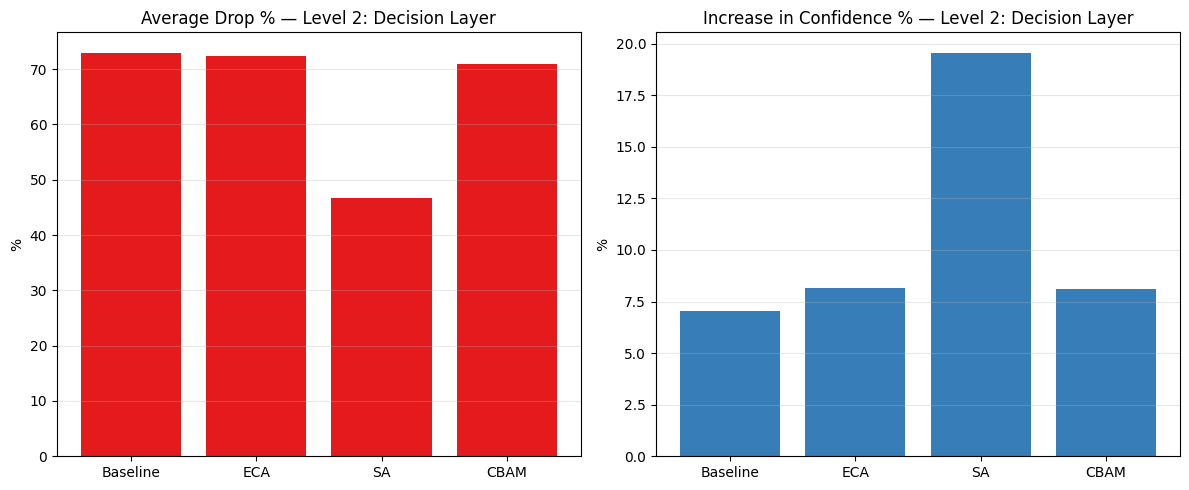

✓ Grafik disimpan -> outputs/GradCAM_Faithfulness_BarChart_Level2.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(results_df_level2["Variant"], results_df_level2["Average_Drop_%"], color="#e41a1c")
axes[0].set_title("Average Drop % — Level 2: Decision Layer")
axes[0].set_ylabel("%")
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].bar(results_df_level2["Variant"], results_df_level2["Increase_in_Confidence_%"], color="#377eb8")
axes[1].set_title("Increase in Confidence % — Level 2: Decision Layer")
axes[1].set_ylabel("%")
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/GradCAM_Faithfulness_BarChart_Level2.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Grafik disimpan -> outputs/GradCAM_Faithfulness_BarChart_Level2.png")


# **Level 1 vs Level 2 — Ringkasan Berdampingan**

In [22]:
comparison = results_df_level1.merge(
    results_df_level2, on="Variant", suffixes=("_Level1_Layer2", "_Level2_DecisionLayer")
)
comparison = comparison[[
    "Variant",
    "Average_Drop_%_Level1_Layer2", "Average_Drop_%_Level2_DecisionLayer",
    "Increase_in_Confidence_%_Level1_Layer2", "Increase_in_Confidence_%_Level2_DecisionLayer",
]]
comparison.to_csv("outputs/GradCAM_Faithfulness_Level1_vs_Level2.csv", index=False)
comparison


,Variant,Average_Drop_%_Level1_Layer2,Average_Drop_%_Level2_DecisionLayer,Increase_in_Confidence_%_Level1_Layer2,Increase_in_Confidence_%_Level2_DecisionLayer
0,Baseline,84.173150,72.988761,3.698151,7.046477
1,ECA,80.738896,72.354476,4.497751,8.145927
2,SA,84.373424,46.699176,2.723638,19.565217
3,CBAM,83.357312,70.916079,4.247876,8.120940


# **Visualisasi 1 Foto — Bandingkan Heatmap Semua Varian**

  [ECA] Disisipkan ke 16 Bottleneck block (layer1-4).
  [CBAM] Disisipkan ke 16 Bottleneck block (layer1-4).
✓ Disimpan -> outputs/GradCAM_SingleImage_Comparison.png


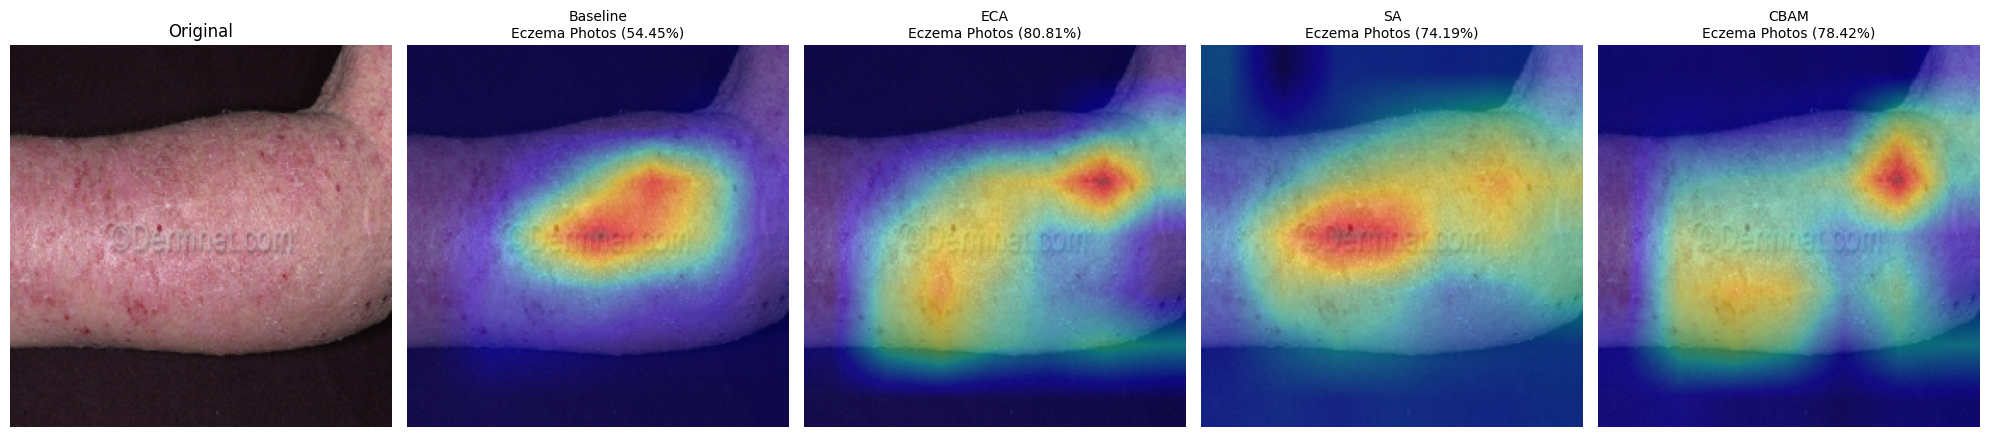

In [23]:
def unnormalize(tensor):
    img = tensor.cpu() * IMAGENET_STD + IMAGENET_MEAN
    img = img.clamp(0, 1).squeeze(0).permute(1, 2, 0).numpy()
    return img


def overlay_cam(image_rgb, cam, alpha=0.45):
    heatmap = matplotlib.cm.jet(cam)[:, :, :3]
    overlay = (1 - alpha) * image_rgb + alpha * heatmap
    return np.clip(overlay, 0, 1)


def compare_single_image(image_path, num_classes, device, save_path=None):
    image = Image.open(image_path).convert("RGB")
    input_tensor = eval_tf(image).unsqueeze(0).to(device)

    variant_names = list(VARIANT_CONFIGS.keys())
    fig, axes = plt.subplots(1, len(variant_names) + 1, figsize=(4 * (len(variant_names) + 1), 4.5))

    original_rgb = unnormalize(input_tensor)
    axes[0].imshow(original_rgb)
    axes[0].set_title("Original")
    axes[0].axis("off")

    for ax, variant_name in zip(axes[1:], variant_names):
        model = load_model(variant_name, num_classes, device)
        target_layer = get_target_layer_decision(model, variant_name)   # pakai Level 2 (decision layer) -- titik paling adil lintas varian
        gradcam = GradCAM(model, target_layer)

        cams, probs, pred_idx = gradcam.generate(input_tensor)
        cam_np   = cams.squeeze(0).cpu().numpy()
        conf     = probs[0, pred_idx[0]].item()
        pred_cls = classes[pred_idx[0].item()]

        overlay = overlay_cam(original_rgb, cam_np)
        ax.imshow(overlay)
        ax.set_title(f"{variant_name}\n{pred_cls} ({conf:.2%})", fontsize=10)
        ax.axis("off")

        gradcam.remove_hooks()
        del model, gradcam
        torch.cuda.empty_cache()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"✓ Disimpan -> {save_path}")
    plt.show()


SAMPLE_IMAGE_PATH = "/kaggle/input/datasets/devianestnarendra/picturetest-gradcam/03DermatitisArm1.jpg" 
compare_single_image(
    SAMPLE_IMAGE_PATH,
    num_classes,
    device,
    save_path="outputs/GradCAM_SingleImage_Comparison.png"
)


# **Visualisasi 1 Foto — Level 1 vs Level 2, Semua Varian**

  [ECA] Disisipkan ke 16 Bottleneck block (layer1-4).
  [CBAM] Disisipkan ke 16 Bottleneck block (layer1-4).
✓ Disimpan -> outputs/GradCAM_SingleImage_Level1_vs_Level2.png


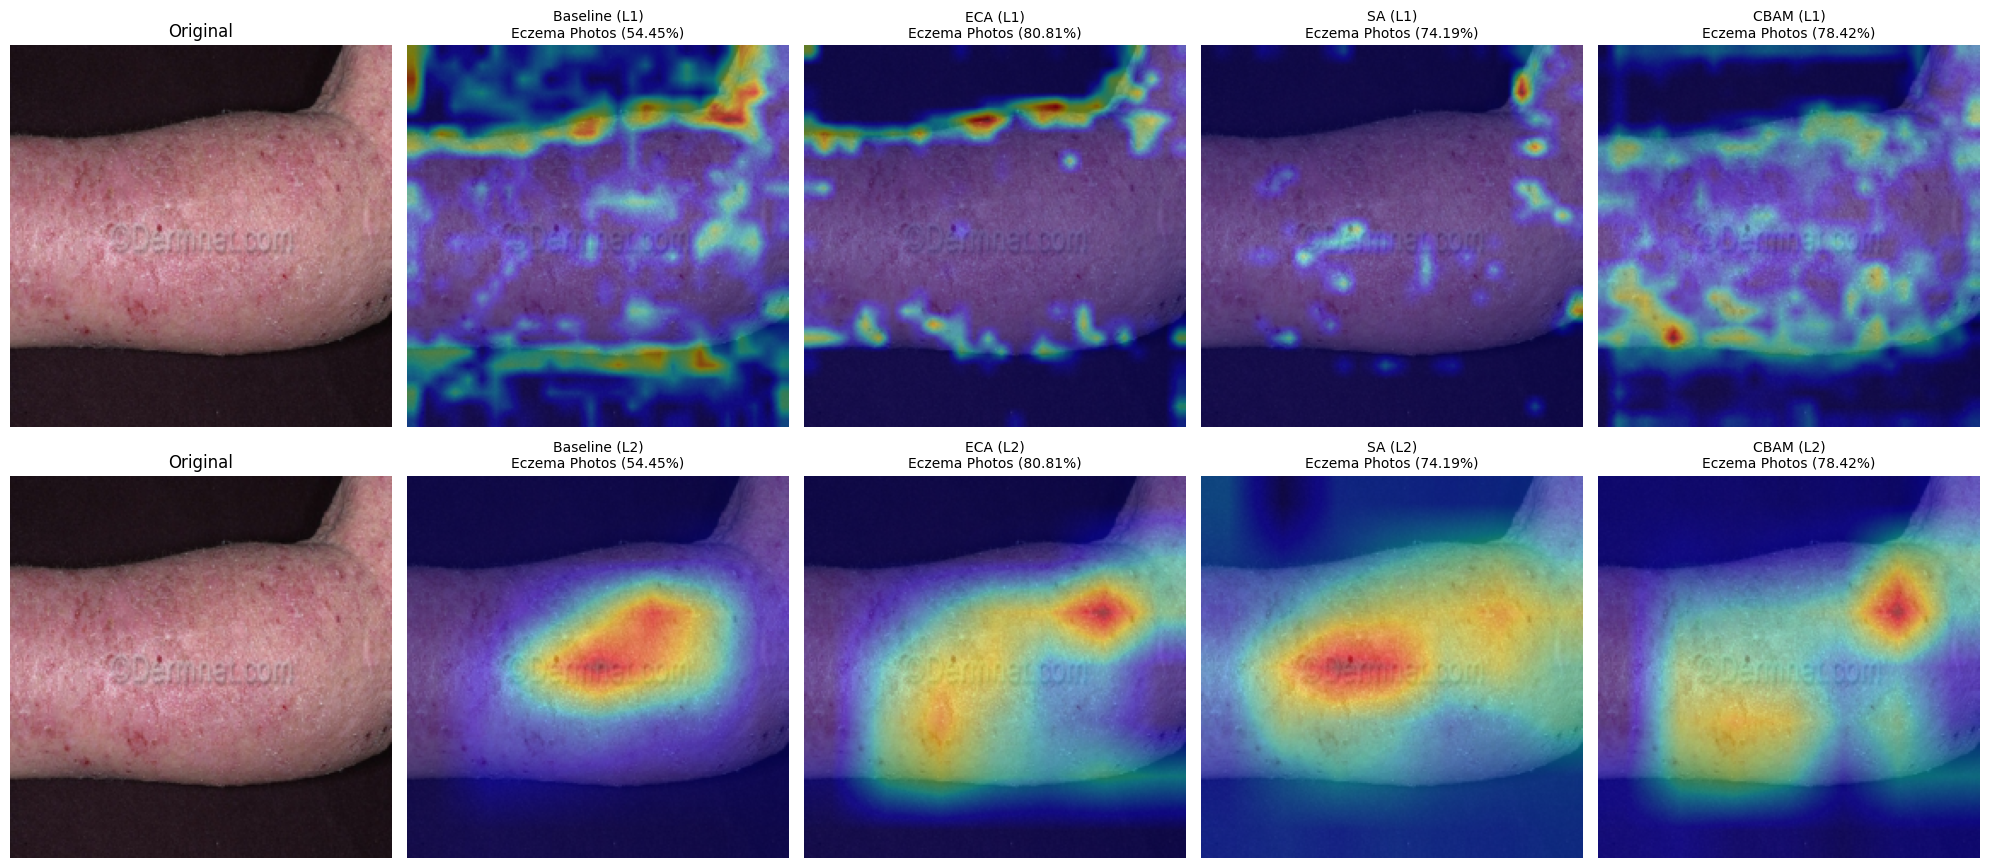

In [24]:
def compare_single_image_both_levels(image_path, num_classes, device, save_path=None):
    """Baris 1 = Level 1 (akhir layer2), baris 2 = Level 2 (decision layer).
    Beda dengan draft sebelumnya, sekarang baris ini TIDAK akan identik --
    tiap varian punya struktur attention beda di 2 titik ini (lihat cell
    markdown paling atas)."""
    image = Image.open(image_path).convert("RGB")
    input_tensor = eval_tf(image).unsqueeze(0).to(device)
    original_rgb = unnormalize(input_tensor)

    variant_names = list(VARIANT_CONFIGS.keys())
    n_cols = len(variant_names) + 1
    fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 9))

    axes[0, 0].imshow(original_rgb); axes[0, 0].set_title("Original"); axes[0, 0].axis("off")
    axes[1, 0].imshow(original_rgb); axes[1, 0].set_title("Original"); axes[1, 0].axis("off")

    for col, variant_name in enumerate(variant_names, start=1):
        model = load_model(variant_name, num_classes, device)

        # ── Level 1: akhir layer2 ──
        target_l1 = get_target_layer(model, variant_name)
        gradcam_l1 = GradCAM(model, target_l1)
        cam_l1, probs_l1, pred_l1 = gradcam_l1.generate(input_tensor)
        overlay_l1 = overlay_cam(original_rgb, cam_l1.squeeze(0).cpu().numpy())
        axes[0, col].imshow(overlay_l1)
        axes[0, col].set_title(
            f"{variant_name} (L1)\n{classes[pred_l1[0].item()]} ({probs_l1[0, pred_l1[0]].item():.2%})",
            fontsize=10
        )
        axes[0, col].axis("off")
        gradcam_l1.remove_hooks()

        # ── Level 2: decision layer ──
        target_l2 = get_target_layer_decision(model, variant_name)
        gradcam_l2 = GradCAM(model, target_l2)
        cam_l2, probs_l2, pred_l2 = gradcam_l2.generate(input_tensor)
        overlay_l2 = overlay_cam(original_rgb, cam_l2.squeeze(0).cpu().numpy())
        axes[1, col].imshow(overlay_l2)
        axes[1, col].set_title(
            f"{variant_name} (L2)\n{classes[pred_l2[0].item()]} ({probs_l2[0, pred_l2[0]].item():.2%})",
            fontsize=10
        )
        axes[1, col].axis("off")
        gradcam_l2.remove_hooks()

        del model, gradcam_l1, gradcam_l2
        torch.cuda.empty_cache()

    axes[0, 0].set_ylabel("Level 1\n(akhir layer2)", fontsize=11)
    axes[1, 0].set_ylabel("Level 2\n(Decision Layer)", fontsize=11)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"✓ Disimpan -> {save_path}")
    plt.show()


compare_single_image_both_levels(
    SAMPLE_IMAGE_PATH,
    num_classes,
    device,
    save_path="outputs/GradCAM_SingleImage_Level1_vs_Level2.png"
)
